In [37]:
import pandas as pd
import numpy as np

In [38]:
df=pd.read_csv('goog1.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df=df.drop('Date', axis=1)
df=scaler.fit_transform(df)

In [40]:
def create_sequences(data, target_col_index, seq_len=5):
    x, y = [], []
    i = seq_len
    while i < len(data):
        x.append(data[i-seq_len:i])             # the last 5 days (past context)
        y.append(data[i][target_col_index])     # the actual price to predict (e.g., today)
        i += 1
    return np.array(x), np.array(y)

X, y = create_sequences(df, target_col_index=3)

In [41]:
# 4. Split
# X = X.reshape((X.shape[0], X.shape[1], 1))
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(len(X_test), len(y_test))

12 12


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 5. Build RNN model
model = Sequential()
model.add(SimpleRNN(50, activation='relu'))
model.add(Dense(1))

# 6. Compile
model.compile(optimizer='adam', loss='mse')

In [49]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0721 
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0690 
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0587 
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0584 
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0584 
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0471 
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0506 
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 0.0441
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 0.0459  
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0421 


In [50]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'MSE: {mse}, R2: {r2}, RMSE: {rmse}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
MSE: 0.05234843980836234, R2: 0.7105337595294157, RMSE: 0.2287978142560858


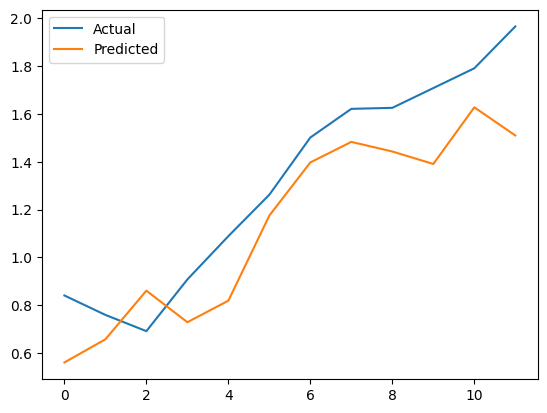

In [51]:
import matplotlib.pyplot as plt

plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()